# Early Feature Fusion MLP Pipeline

## 1. Imports

Import the necessary libraries and custom functions for early fusion training:
- Standard libraries: NumPy, Pandas, Matplotlib
- Custom utilities: Cross-validation and hyperparameter tuning functions for early fusion MLPs

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))

# EarlyFusion models
from FusionModels.utils import cross_validation_5fold_early_fusion, hyperparameter_tuning

## 2. Concatenation

The audio and tapping features dataframes are concatenated into a single features dataframe. This, in turn, will be fed to the MLP. 

Note that, each patient has either more tapping trials or more audio trials. To deal with this, for each patient we randomely downsample the number of trials in the dataframe that contains more trials, for that patient, to have exactly the minimum number of trials that originally existed in either CSV. This is needed as our concatenation is actually a column binding.

In [ ]:
AUDIO_FEATURES = "/mloscratch/users/gnahas/data/features/acoustic_features_vf.csv"
TAPPING_FEATURES = "/mloscratch/users/clerget/data/csv/tapping_combined_features_session.csv"

audio_features = pd.read_csv(AUDIO_FEATURES)
tapping_features = pd.read_csv(TAPPING_FEATURES)

# Rename 'healthcode' to 'healthCode' for consistency if needed
if 'healthcode' in audio_features.columns and 'healthCode' not in audio_features.columns:
    audio_features = audio_features.rename(columns={'healthcode': 'healthCode'})

if 'healthcode' in tapping_features.columns and 'healthCode' not in TAPPING_FEATURES.columns:
    tapping_features = tapping_features.rename(columns={'healthcode': 'healthCode'})

# Count occurrences of trials per patient in each dataframe
counts_audio = audio_features["healthCode"].value_counts()
counts_tapping = tapping_features["healthCode"].value_counts()

# Consider healthCodes present in both files
shared_healthCodes = counts_audio.index.intersection(counts_tapping.index)

# Helper: minimum count of trials for each patient
min_counts = {code: min(counts_audio[code], counts_tapping[code]) for code in shared_healthCodes}

# Dropping extra audio trials per patient where needed
counts_audio_balanced = (
    audio_features[audio_features["healthCode"].isin(shared_healthCodes)]
      .groupby("healthCode")
      .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
      .reset_index(drop=True)
)

# Dropping extra tapping trials per patient where needed
counts_tapping_balanced = (
    tapping_features[tapping_features["healthCode"].isin(shared_healthCodes)]
      .groupby("healthCode")
      .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
      .reset_index(drop=True)
)

counts_audio_balanced["row_id"] = counts_audio_balanced.groupby("healthCode").cumcount()
counts_tapping_balanced["row_id"] = counts_tapping_balanced.groupby("healthCode").cumcount()

# Verify that there are the same amount of trials in both dataframes
print("Balanced trials count match:", len(counts_audio_balanced) == len(counts_tapping_balanced))

# Verify that heatlthCodes are properly aligned
print("Columns aligned:", all(
    counts_audio_balanced["healthCode"].values == counts_tapping_balanced["healthCode"].values
))

features_merged = pd.merge(
    counts_audio_balanced,
    counts_tapping_balanced,
    on=["healthCode", "row_id"],
    suffixes=("_file1", "_file2")
)

features_merged.to_csv("/tremor2tensor/src_GAMMA/fusion_features.csv", index=False)


/tmp/ipykernel_20027/219091561.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
/tmp/ipykernel_20027/219091561.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min_counts[g.name], random_state=42))


Balanced trials count match: True
Columns aligned: True


## 3. Data Loading

Load the fused features from the previous concatenation step, along with:
- **Labels**: Patient diagnoses (PD vs. Control) 
- **Train folds**: Patient assignments for training set across 5 folds
- **Val/Test folds**: Patient assignments for validation and test sets across 5 folds

These files define the cross-validation strategy and ensure patient-level splits (no data leakage).

In [ ]:
FUSION_FEATURES = "/tremor2tensor/src_GAMMA/fusion_features.csv"
LABELS = "/tremor2tensor/src_GAMMA/paired_healthcode.csv"
TRAIN_FOLDS = "/tremor2tensor/src_GAMMA/5_fold_CV/processed_paired/paired_splits/balanced_train/healthcode_5fold_train.csv"
VAL_TEST_FOLDS = "/tremor2tensor/src_GAMMA/5_fold_CV/processed_paired/paired_splits/balanced_train/healthcode_5fold_val_test.csv"

## 4. Cross-Validation & Hyperparameter Tuning 

Perform exhaustive grid search to find the optimal MLP configuration:
1. **Grid Search**: Test all combinations of hyperparameters (hidden layers, batch size, learning rate, dropout, weight decay, class weights, epochs)
2. **5-Fold Cross-Validation**: Evaluate each configuration using patient-stratified 5-fold CV
3. **Model Selection**: Choose the best model based on patient-level ROC AUC score
4. **Early Stopping**: Automatically stops training when validation performance plateaus
5. **Model Saving**: Save the best model weights for each fold

The MLP processes the concatenated audio+tapping features through multiple hidden layers for binary classification.

In [4]:
output_dir_mlp = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/models/EarlyFusion/"

hyperparam_tuning_res = hyperparameter_tuning(
    features_csv = FUSION_FEATURES,
    labels_csv = LABELS,
    train_folds_csv = TRAIN_FOLDS,
    val_test_folds_csv = VAL_TEST_FOLDS,
    output_dir = output_dir_mlp,
    hidden_dims = [[256, 128, 64]],
    batch_size = [64],
    weight_decay = [0.0001],
    dropout = [0.75],
    class_weight = [3.0],
    num_epochs = [150],
    learning_rate = [0.001],
    verbose = True        
)

Testing 1 Hyperparameter Combinations

------------------------------
Hyperparameters; set 1/1
------------------------------
Hidden Layers: [256, 128, 64]
Batch Size: 64
Weight Decay: 0.0001
Dropout: 0.75
Class Weight: 3.0
Num Epochs: 150
Learning Rate: 0.001
------------------------------ 



/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/FusionModels/MLP.py:160: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/native/Scalar.cpp:22.)
  epoch_loss += loss.item() * len(lbl)
/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/FusionModels/utils.py:247: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_data_standardized['fold'] = fold
/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/FusionModels/utils.py:247: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using

Results Summary
------------------------------
Test Accuracy: 0.6363 ± 0.0464
Test F1 Score: 0.7281 ± 0.0462
Test ROC AUC (Session): 0.7227 ± 0.0690
Test ROC AUC (Patient): 0.7445 ± 0.0460
------------------------------ 

Found New Best Model!
------------------------------ 

------------------------------
End Summary
------------------------------
Hyperparameters
------------------------------
Hidden Layers: [256, 128, 64]
Batch Size: 64
Weight Decay: 0.0001
Dropout: 0.75
Class Weight: 3.0
Num Epochs: 150
Learning Rate: 0.001
------------------------------
Best Model Results
------------------------------
Best Test Accuracy: 0.6363 ± 0.0464
Best Test F1 Score: 0.7281 ± 0.0462
Best Test ROC AUC (Session): 0.7227 ± 0.0690
Best Test ROC AUC (Patient): 0.7445 ± 0.0460
------------------------------ 

Saved Best Model at the following Path: /mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/models/EarlyFusion/model_fold_4.pth


/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/FusionModels/utils.py:247: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_data_standardized['fold'] = fold


## 5. Results Visualization

Visualize the performance of the best early fusion model across all 5 folds:

**Confusion Matrices (Plots 1-5)**: 
- Show the classification performance for each fold
- Display true positives, false positives, true negatives, and false negatives
- Color-coded heatmap for easy interpretation

**Performance Metrics Bar Chart (Plot 6)**:
- **Accuracy**: Overall classification accuracy
- **F1 Score**: Harmonic mean of precision and recall
- **ROC AUC (Session)**: Computed on individual trials without patient aggregation
- **ROC AUC (Patient)**: Computed after averaging probabilities per patient (more clinically relevant)

All metrics include error bars showing ± one standard deviation across the 5 folds.

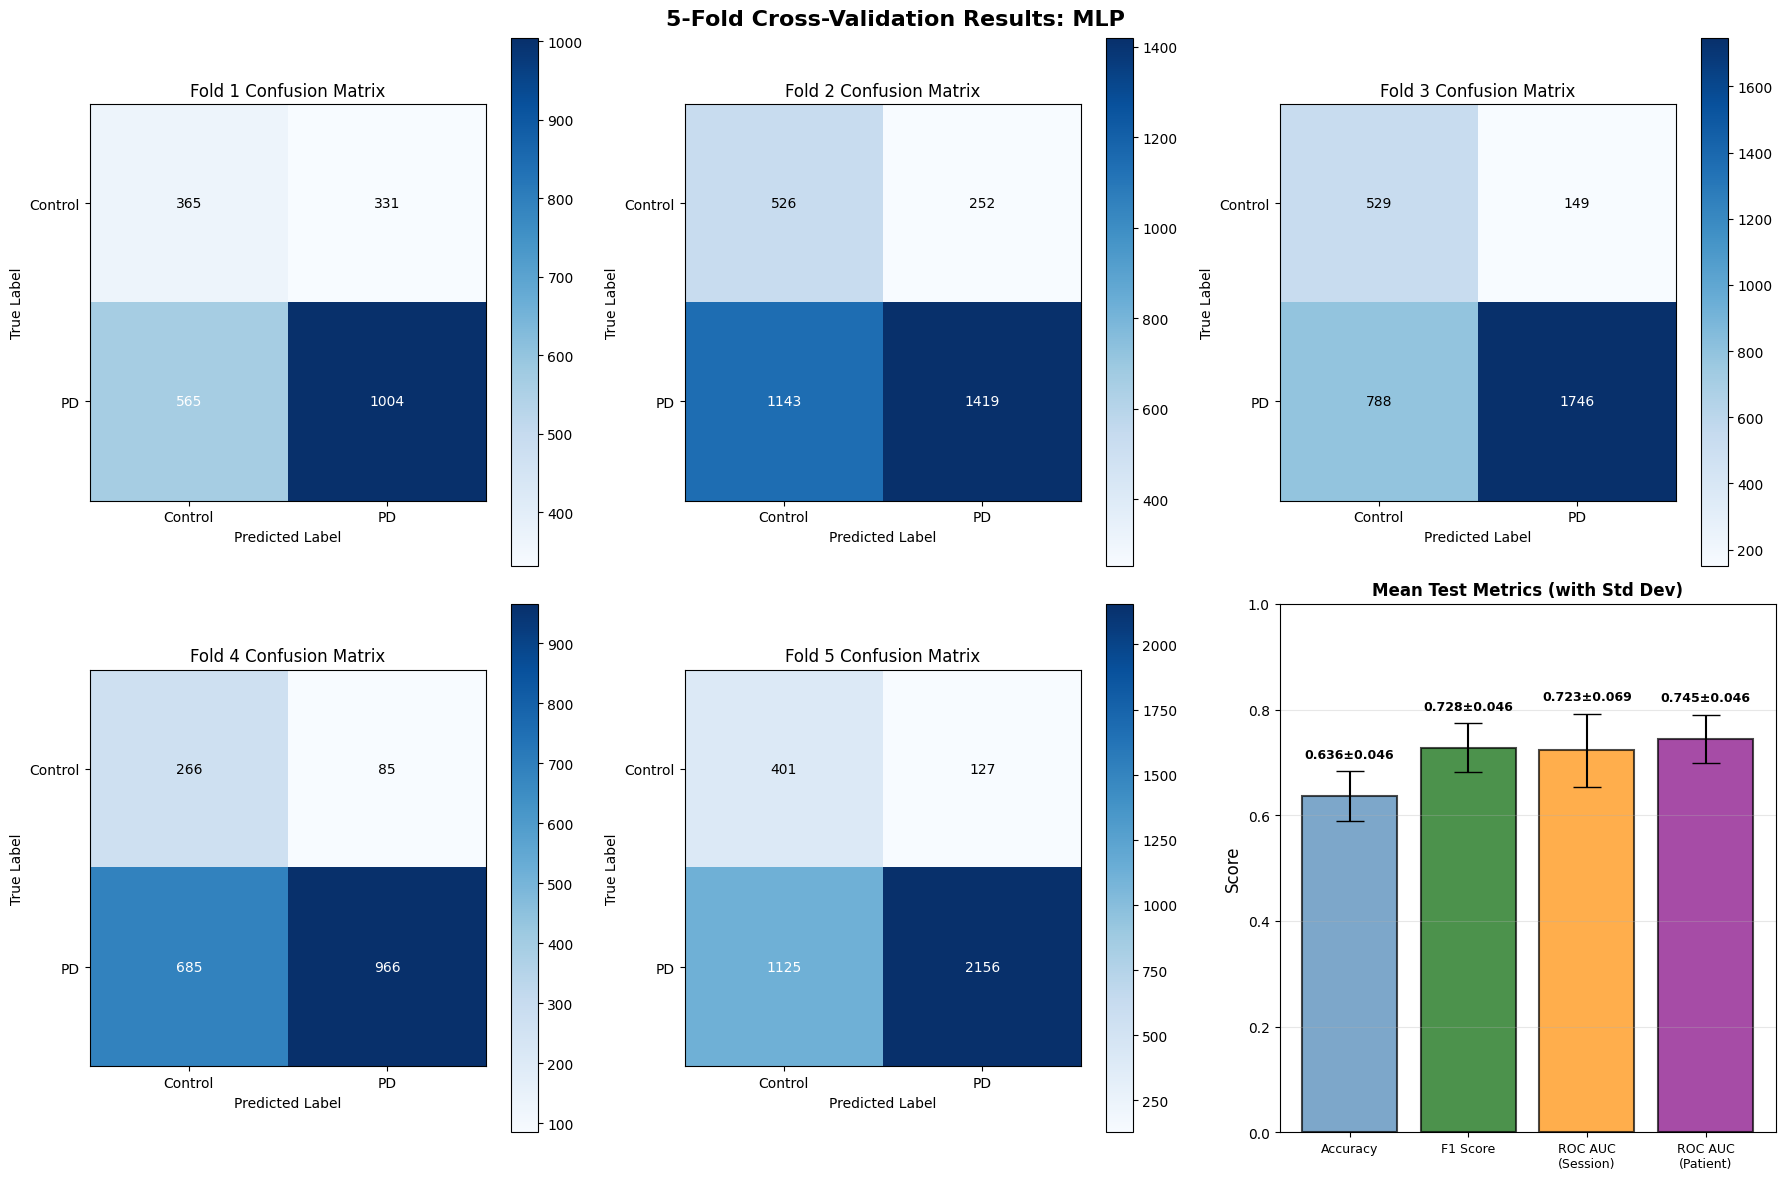


Summary Statistics:
Test Accuracy: 0.6363 ± 0.0464
Test F1 Score: 0.7281 ± 0.0462
Test ROC AUC (Session-level): 0.7227 ± 0.0690
Test ROC AUC (Patient-level):  0.7445 ± 0.0460


In [5]:
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('5-Fold Cross-Validation Results: MLP', fontsize=16, fontweight='bold')

# Plot confusion matrices for each fold
for i, cm in enumerate(hyperparam_tuning_res['confusion_matrices']):
    if i < 5:  # We have 5 folds
        row = i // 3
        col = i % 3
        ax = axes[row, col]
        
        # Plot confusion matrix as heatmap
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.set_title(f'Fold {i + 1} Confusion Matrix')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        
        # Add colorbar
        plt.colorbar(im, ax=ax)
        
        # Add text annotations
        thresh = cm.max() / 2.
        for row_idx in range(cm.shape[0]):
            for col_idx in range(cm.shape[1]):
                ax.text(col_idx, row_idx, format(cm[row_idx, col_idx], 'd'),
                       ha="center", va="center",
                       color="white" if cm[row_idx, col_idx] > thresh else "black")
        
        # Set ticks
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Control', 'PD'])
        ax.set_yticklabels(['Control', 'PD'])

# Plot mean metrics with error bars in the last subplot
ax = axes[1, 2]
metrics = ['Accuracy', 'F1 Score', 'ROC AUC\n(Session)', 'ROC AUC\n(Patient)']
means = [hyperparam_tuning_res['mean_test_acc'], 
         hyperparam_tuning_res['mean_test_f1'], 
         hyperparam_tuning_res['mean_test_roc_auc_session'],
         hyperparam_tuning_res['mean_test_roc_auc_patient']]
stds = [hyperparam_tuning_res['std_test_acc'], 
        hyperparam_tuning_res['std_test_f1'], 
        hyperparam_tuning_res['std_test_roc_auc_session'],
        hyperparam_tuning_res['std_test_roc_auc_patient']]

x_pos = np.arange(len(metrics))
bars = ax.bar(x_pos, means, yerr=stds, align='center', alpha=0.7, 
              color=['steelblue', 'darkgreen', 'darkorange', 'purple'], 
              ecolor='black', capsize=10, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Mean Test Metrics (with Std Dev)', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics, fontsize=9)
ax.set_ylim([0, 1.0])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (mean, std) in enumerate(zip(means, stds)):
    ax.text(i, mean + std + 0.02, f'{mean:.3f}±{std:.3f}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"Test Accuracy: {hyperparam_tuning_res['mean_test_acc']:.4f} ± {hyperparam_tuning_res['std_test_acc']:.4f}")
print(f"Test F1 Score: {hyperparam_tuning_res['mean_test_f1']:.4f} ± {hyperparam_tuning_res['std_test_f1']:.4f}")
print(f"Test ROC AUC (Session-level): {hyperparam_tuning_res['mean_test_roc_auc_session']:.4f} ± {hyperparam_tuning_res['std_test_roc_auc_session']:.4f}")
print(f"Test ROC AUC (Patient-level):  {hyperparam_tuning_res['mean_test_roc_auc_patient']:.4f} ± {hyperparam_tuning_res['std_test_roc_auc_patient']:.4f}")
